# Project Title

# Problem Statement

# Project Architecture

# Tech Stack

# Import Liabraries

In [1]:
import pandas as pd
import numpy as np
import re
import string
import pickle

from bs4 import BeautifulSoup
import nltk

nltk.download('stopwords')
nltk.download('wordnet')

import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, f1_score, recall_score, roc_auc_score,roc_curve

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier


import warnings 
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Data Gathering

In [2]:
df = pd.read_csv("fake_job_postings.csv")
df.head(2)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0


# Check Missing Values

In [3]:
null_percent = round((df.isnull().sum()/len(df))*100,2)
print(null_percent.sort_values(ascending=False))

salary_range           83.96
department             64.58
required_education     45.33
benefits               40.34
required_experience    39.43
function               36.10
industry               27.42
employment_type        19.41
company_profile        18.50
requirements           15.08
location                1.94
description             0.01
title                   0.00
job_id                  0.00
telecommuting           0.00
has_questions           0.00
has_company_logo        0.00
fraudulent              0.00
dtype: float64


# Text Cleaning Function

In [4]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    if pd.isna(text):
        return ''

    text = BeautifulSoup(str(text),'html.parser').get_text()

    text = text.lower()

    text = re.sub(r'http\S+|www\S+','',text)

    text = re.sub(r'[^a-zA-Z0-9]',' ',text)

    text = re.sub(r'\s+',' ',text).strip()

    words = []

    for word in text.split():
        if word not in stop_words:
            words.append(lemmatizer.lemmatize(word))

    return ' '.join(words)

# Combine Text Column

In [5]:
text_columns = [
    'title',
    'company_profile',
    'description',
    'requirements',
    'benefits'
]

In [6]:
# Fill missing values
df[text_columns] = df[text_columns].fillna('')

In [7]:
# create combine text
df['text'] = (
    df['title'] + ' ' +
    df['company_profile'] + ' ' +
    df['description'] + ' ' +
    df['requirements'] + ' ' +
    df['benefits']
)

In [8]:
# applying on clean text
df['text'] = df['text'].apply(clean_text)

# Handle Categorical Features

In [9]:
categorical_features = [
    'employment_type',
    'required_experience',
    'required_education',
    'industry',
    'function',
    'salary_range'
]

In [10]:
for col in categorical_features:
    df[col] = df[col].fillna('Unknown')

# Numerical Features

In [11]:
numerical_features = [
    'telecommuting',
    'has_company_logo',
    'has_questions'
]

# Define X and Y

In [12]:
X = df[['text'] + categorical_features + numerical_features]
y = df['fraudulent']

In [13]:
# our data is imbalanced
y.value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

# Train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

# Create Preprocessor

In [15]:
text_transformer = TfidfVectorizer(
    max_features=5000,   # keep only top 5000 important words
    min_df=2,            # ignore words that appear in fewer than 2 documents
    max_df=0.95,         # ignore words that appear in more than 95% of documents
    stop_words='english' # remove common English stopwords
)


categorical_transformer = OneHotEncoder(
    handle_unknown='ignore'  # ignore unseen categories during prediction
)


preprocessor = ColumnTransformer(
    transformers=[
        # Apply TF-IDF to the 'text' column
        ('text_features', text_transformer, 'text'),

        # One-hot encode categorical columns
        ('categorical_features', categorical_transformer, categorical_features),

        # Keep numerical columns as they are
        ('numerical_features', 'passthrough', numerical_features)
    ]
)

# Applying Logistic Regression

In [16]:
lr_pipeline = Pipeline([
    ('preprocessor',
        preprocessor
    ),

    (
        'classifier',
        LogisticRegression(max_iter=3000,class_weight='balanced')
    )
])

In [17]:
lr_pipeline.fit( X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text_features',
                                                  TfidfVectorizer(max_df=0.95,
                                                                  max_features=5000,
                                                                  min_df=2,
                                                                  stop_words='english'),
                                                  'text'),
                                                 ('categorical_features',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['employment_type',
                                                   'required_experience',
                                                   'required_education',
                                                   'industry', 'function',
                                                   'salary_range']),
                                                 ('numerical_features',
                                                  'passthrough',
                                                  ['telecommuting',
                                                   'has_company_logo',
                                                   'has_questions'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=3000))])

# Applying XGBoost

In [18]:
# for imbalance class
scale_pos_weight = 17014 / 866
print(scale_pos_weight)

19.64665127020785


In [19]:
xg_pipeline = Pipeline([
    ('preprocessor', preprocessor),

    ('classifier',
     XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
     ))
])

In [20]:
xg_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text_features',
                                                  TfidfVectorizer(max_df=0.95,
                                                                  max_features=5000,
                                                                  min_df=2,
                                                                  stop_words='english'),
                                                  'text'),
                                                 ('categorical_features',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['employment_type',
                                                   'required_experience',
                                                   'required_education',
                                                   'industry', 'function',
                                                   'salary_range']),
                                                 ('numerical_features...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

# Applying Random Forest

In [21]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),

    ('classifier',
     RandomForestClassifier( n_estimators=300,random_state=42,class_weight='balanced',n_jobs=-1))
])

In [22]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text_features',
                                                  TfidfVectorizer(max_df=0.95,
                                                                  max_features=5000,
                                                                  min_df=2,
                                                                  stop_words='english'),
                                                  'text'),
                                                 ('categorical_features',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['employment_type',
                                                   'required_experience',
                                                   'required_education',
                                                   'industry', 'function',
                                                   'salary_range']),
                                                 ('numerical_features',
                                                  'passthrough',
                                                  ['telecommuting',
                                                   'has_company_logo',
                                                   'has_questions'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

# Comparision of all three Models

In [23]:
results = []

### Logistic Regression

In [24]:
# Predictions
y_pred_lr = lr_pipeline.predict(X_test)

# Probabilities
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1 Score': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_prob_lr)
})

### XGBoost

In [25]:
# Predictions
y_pred_xgb = xg_pipeline.predict(X_test)

# Probabilities
y_prob_xgb = xg_pipeline.predict_proba(X_test)[:, 1]

results.append({
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1 Score': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_prob_xgb)
})

### Random Forest

In [26]:
# Predication
y_pred_rf = rf_pipeline.predict(X_test)

#Probabilities
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1 Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_prob_rf)
})

## Comparison of all Models

In [27]:
comparison_df = pd.DataFrame(results)
comparison_df.sort_values( by='F1 Score', ascending=False, inplace=True)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,XGBoost,0.987696,0.886228,0.855491,0.870588,0.991685
2,Random Forest,0.979866,1.000000,0.583815,0.737226,0.992144
0,Logistic Regression,0.967282,0.612903,0.878613,0.722090,0.985176


## Visualize Comparison

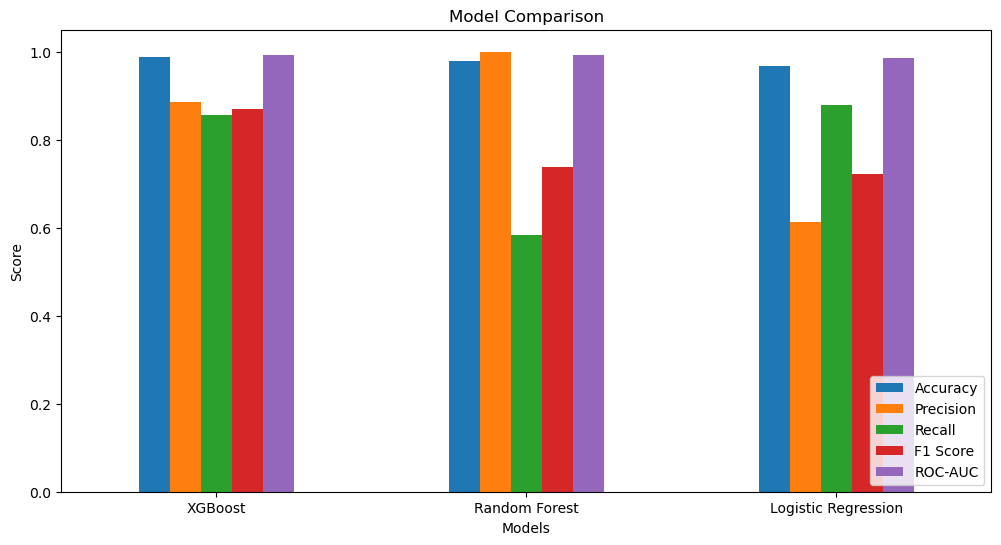

In [28]:
comparison_df.plot(x='Model',y=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],kind='bar',figsize=(12,6))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xlabel('Models')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')

plt.show()

### Confusion Matrix for XGBoost

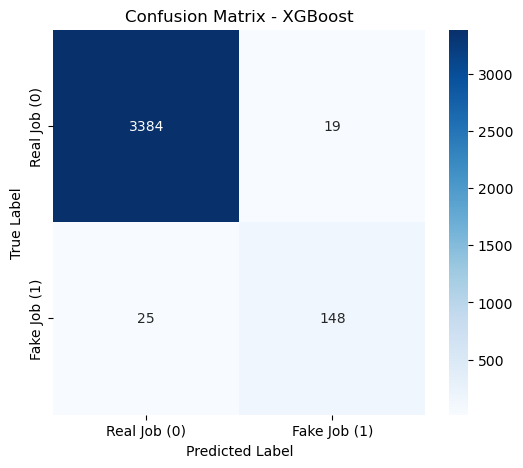

In [29]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Real Job (0)', 'Fake Job (1)'],
    yticklabels=['Real Job (0)', 'Fake Job (1)']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - XGBoost')
plt.show()

### ROC Curve Graph For XGBoost

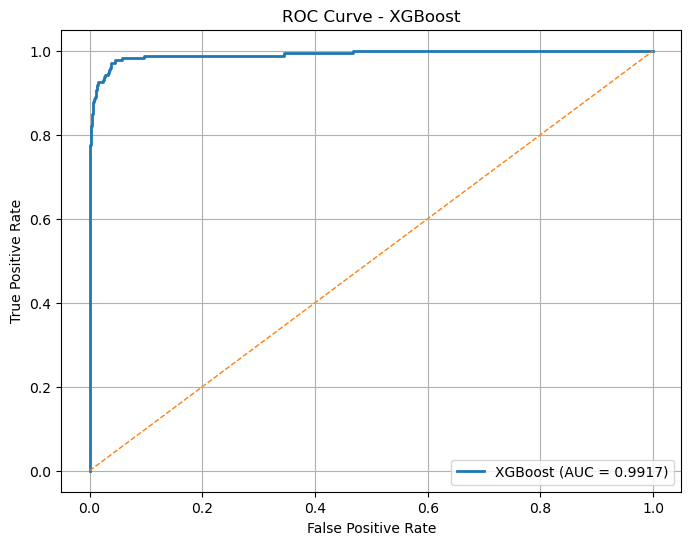

In [30]:
# ROC Curve Data
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob_xgb)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, linewidth=2, label=f'XGBoost (AUC = {roc_auc:.4f})')

# Random Classifier Line
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

### Comparison of Cross validation

In [31]:
# Logistic Regression
lr_scores = cross_val_score(lr_pipeline, X, y, cv=5, scoring='f1')

# Random Forest
rf_scores = cross_val_score(rf_pipeline, X, y, cv=5, scoring='f1')

# XGBoost
xgb_scores = cross_val_score(xg_pipeline, X, y, cv=5, scoring='f1')

print("Logistic Regression:", lr_scores.mean())
print("Random Forest:", rf_scores.mean())
print("XGBoost:", xgb_scores.mean())

Logistic Regression: 0.6509406316180938
Random Forest: 0.6578250304843247
XGBoost: 0.8050409416417079


### Now we applying Hyperparameter Tuning

In [35]:
# these are the parameters we use 

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.01, 0.05],
    'classifier__subsample': [0.8, 0.9],
    'classifier__colsample_bytree': [0.8, 0.9],
    'classifier__min_child_weight': [1, 3]
}

In [36]:
random_search = RandomizedSearchCV(
    estimator=xg_pipeline,
    param_distributions=param_grid,
    n_iter=5,
    scoring='f1',
    cv=2,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [37]:
random_search.fit(X_train, y_train)

Fitting 2 folds for each of 5 candidates, totalling 10 fits


RandomizedSearchCV(cv=2,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('text_features',
                                                                               TfidfVectorizer(max_df=0.95,
                                                                                               max_features=5000,
                                                                                               min_df=2,
                                                                                               stop_words='english'),
                                                                               'text'),
                                                                              ('categorical_features',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['employment_type',
                                                                                'required_experience',
                                                                                'required_education',
                                                                                'industry',
                                                                                'function',
                                                                                'sa...
                                                            n_estimators=300,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'classifier__colsample_bytree': [0.8,
                                                                         0.9],
                                        'classifier__learning_rate': [0.01,
                                                                      0.05],
                                        'classifier__max_depth': [3, 5],
                                        'classifier__min_child_weight': [1, 3],
                                        'classifier__n_estimators': [100, 200],
                                        'classifier__subsample': [0.8, 0.9]},
                   random_state=42, scoring='f1', verbose=2)

In [38]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest F1 Score:")
print(random_search.best_score_)

Best Parameters:
{'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 1, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.9}

Best F1 Score:
0.664432722241439


In [39]:
best_xg = random_search.best_estimator_

In [40]:
y_pred = best_xg.predict(X_test)
y_prob = best_xg.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9630872483221476
Precision: 0.5767790262172284
Recall   : 0.8901734104046243
F1 Score : 0.7
ROC-AUC  : 0.9901667858519939


## Comparison with tuning and without tuning

In [42]:
# Baseline model predictions
y_pred_base = xg_pipeline.predict(X_test)
y_prob_base = xg_pipeline.predict_proba(X_test)[:, 1]

baseline_results = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base),
    "Recall": recall_score(y_test, y_pred_base),
    "F1 Score": f1_score(y_test, y_pred_base),
    "ROC-AUC": roc_auc_score(y_test, y_prob_base)
}

In [43]:
# Best tuned model
best_model = random_search.best_estimator_

y_pred_tuned = best_xg.predict(X_test)
y_prob_tuned = best_xg.predict_proba(X_test)[:, 1]

tuned_results = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1 Score": f1_score(y_test, y_pred_tuned),
    "ROC-AUC": roc_auc_score(y_test, y_prob_tuned)
}

In [44]:
comparison_df = pd.DataFrame({
    "Without Tuning": baseline_results,
    "With Tuning": tuned_results
})

comparison_df

,Without Tuning,With Tuning
Accuracy,0.987696,0.963087
Precision,0.886228,0.576779
Recall,0.855491,0.890173
F1 Score,0.870588,0.700000
ROC-AUC,0.991685,0.990167


## Visulize comparison with tuning and without tuning

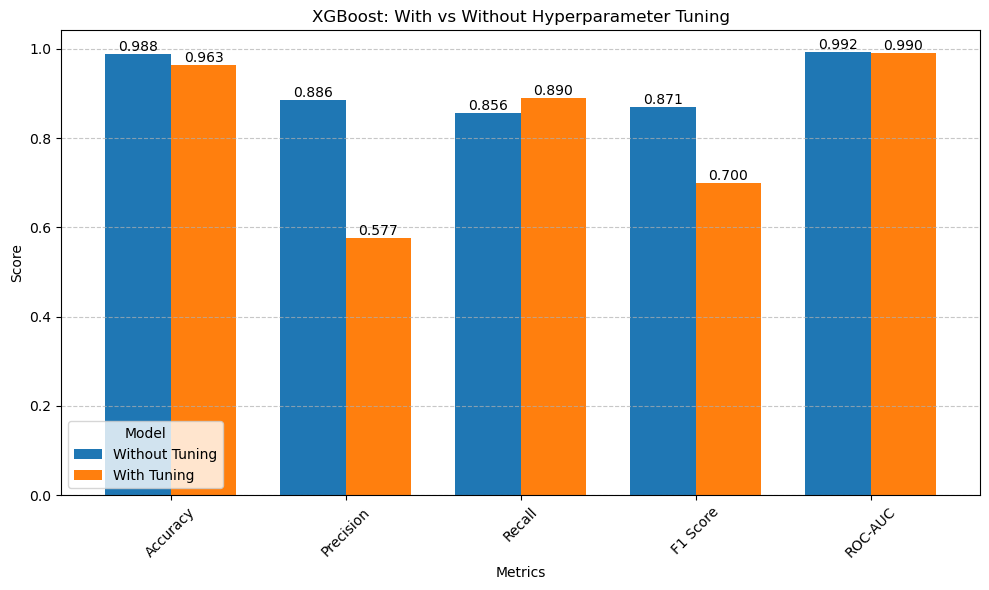

In [47]:
ax = comparison_df.plot(kind="bar", figsize=(10, 6), width=0.75)
plt.title("XGBoost: With vs Without Hyperparameter Tuning")
plt.ylabel("Score")
plt.xlabel("Metrics")
plt.xticks(rotation=45)
plt.legend(title="Model")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Bar values show karne ke liye
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

### After Noticing the comparison with tuning and without tuning the Insight is 

In [ ]:
Maine RandomizedSearchCV use karke XGBoost tune kiya. 
Tuning ke baad Recall thoda improve hua, lekin Precision aur 
F1 Score reduce ho gaye.Isliye final deployment ke liye baseline 
XGBoost select kiya,kyunki uska overall F1 Score aur Precision better tha.

### Step 1: saving our best model

In [32]:
import joblib

joblib.dump(xg_pipeline, "fake_job_detector.pkl")

['fake_job_detector.pkl']

### Step 2: veriffying the model

In [33]:
model = joblib.load('fake_job_detector.pkl')
print(type(model))

<class 'sklearn.pipeline.Pipeline'>
